In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.font_manager as font_manager
from adjustText import adjust_text

font_dir = Path("/Users/sophiazhang/anaconda3/envs/shuoz/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf")
font_paths = [
    font_dir / "Myriad Pro Regular.ttf",
    font_dir / "Myriad Pro Bold.ttf",
    font_dir / "MYRIADPRO-SEMIBOLD.OTF"
]

for path in font_paths:
    font_manager.fontManager.addfont(str(path))

plt.rcParams["font.family"] = "Myriad Pro"

fs=16
fss=14

In [14]:
RESULTS_DIR = Path("./results")
CSV_SECTOR = RESULTS_DIR / "sector_level_digital_metrics_2000_2020.csv"
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(CSV_SECTOR)
df["year"] = df["year"].astype(int)
df00 = df[df["year"] == 2000].copy()
df08 = df[df["year"] == 2008].copy()
df13 = df[df["year"] == 2013].copy() 
df20 = df[df["year"] == 2020].copy()


def save_tight(fig, filename, dpi=300):
    fp = RESULTS_DIR / filename
    fig.tight_layout()
    fig.savefig(fp, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {fp}")

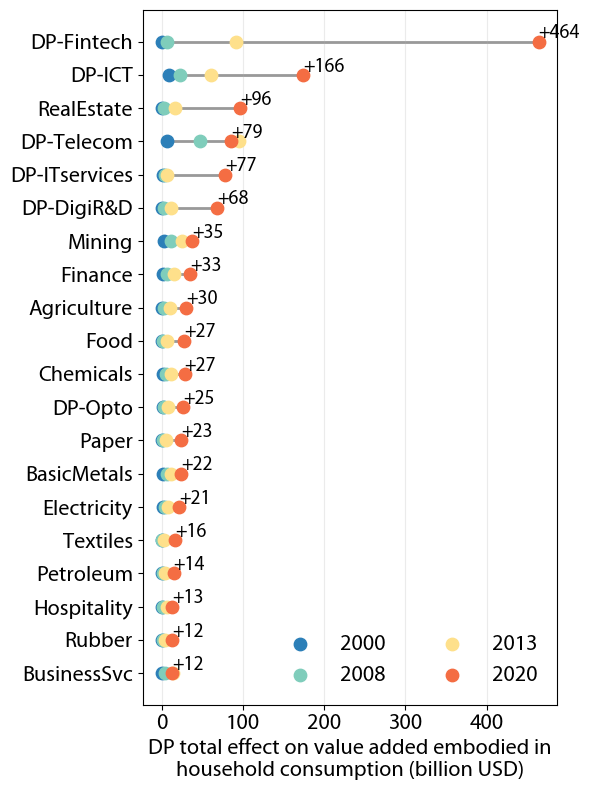

Saved: results/top20_DP_TotalEffect_selected_years.png


In [18]:
selected_years = [2000, 2008, 2013, 2020]
top_n = 20
eps = 1e-12
year_colors = {
    2000: "#2C7FB8", 2008: "#7FCDBB", 2013: "#FEE08B", 2020: "#F46D43"}

df_sel = df[df["year"].isin(selected_years)].copy()
# million -> billion
value_cols = [
    "DP_TotalEffect_t_i", "DP_Support_t_i", "DP_FinalDemand_t_i", "TotalVA_t_i"]
for col in value_cols:
    df_sel[col] = df_sel[col] / 1000

# Select top sectors by increase from 2000 to 2020
df_wide = (
    df_sel[df_sel["year"].isin([2000, 2020])]
    .pivot_table(
        index=["sector_index", "sector_name", "group"],
        columns="year",
        values="DP_TotalEffect_t_i",
        aggfunc="sum")
    .reset_index())

df_wide["delta_2000_2020"] = df_wide[2020] - df_wide[2000]
top_sectors = (
    df_wide
    .sort_values("delta_2000_2020", ascending=False)
    .head(top_n)["sector_index"]
    .tolist())

df_plot_long = df_sel[df_sel["sector_index"].isin(top_sectors)].copy()

# sector order based on 2000-2020 increase
sector_order = (
    df_wide[df_wide["sector_index"].isin(top_sectors)]
    .sort_values("delta_2000_2020", ascending=True)["sector_index"]
    .tolist())

sector_labels = (
    df_wide[df_wide["sector_index"].isin(sector_order)]
    .set_index("sector_index")
    .loc[sector_order, "sector_name"]
    .tolist())

fig, ax = plt.subplots(figsize=(6, 8), facecolor="none")
y_pos = np.arange(len(sector_order))
for y, sector_id in zip(y_pos, sector_order):
    g = (
        df_plot_long[df_plot_long["sector_index"] == sector_id]
        .sort_values("year"))
    x_values = g["DP_TotalEffect_t_i"].values
    years = g["year"].values
    # connecting line across years
    ax.plot(
        x_values,
        [y] * len(x_values),
        color="#555555",
        linewidth=2,
        alpha=0.6,
        zorder=1)

    # points for selected years
    for yr in selected_years:
        g_yr = g[g["year"] == yr]
        if not g_yr.empty:
            ax.scatter(
                g_yr["DP_TotalEffect_t_i"].iloc[0],
                y,
                color=year_colors[yr],
                s=80,
                label=str(yr) if y == 0 else None,
                zorder=2)

    # optional: annotate total increase from 2000 to 2020
    x_2000 = g.loc[g["year"] == 2000, "DP_TotalEffect_t_i"]
    x_2020 = g.loc[g["year"] == 2020, "DP_TotalEffect_t_i"]
    if len(x_2000) > 0 and len(x_2020) > 0:
        delta = x_2020.iloc[0] - x_2000.iloc[0]
        ax.text(
            x_2020.iloc[0],
            y + 0.25,
            f"+{delta:,.0f}",
            va="center",
            ha="left",
            fontsize=fss)
ax.set_yticks(y_pos)
ax.set_yticklabels(sector_labels, fontsize=fs)
ax.set_xlabel(
    "DP total effect on value added embodied in\nhousehold consumption (billion USD)",
    fontsize=fs)
ax.tick_params(axis="x", labelsize=fs)
ax.legend(fontsize=fs, frameon=False, ncol=2, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.set_facecolor("none")
fig.tight_layout()
save_tight(fig, f"top{top_n}_DP_TotalEffect_selected_years.png")
plt.show()

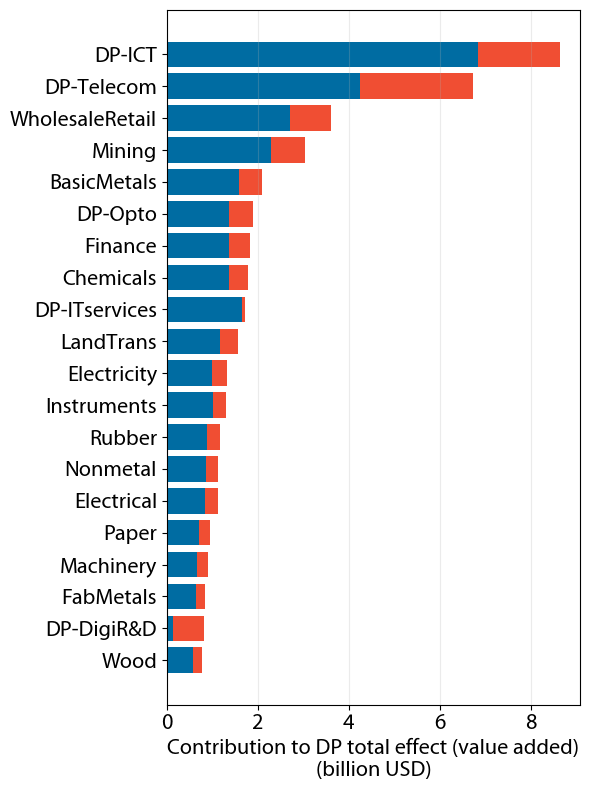

Saved: results/top20_DP_effect_decomposition_2000.png


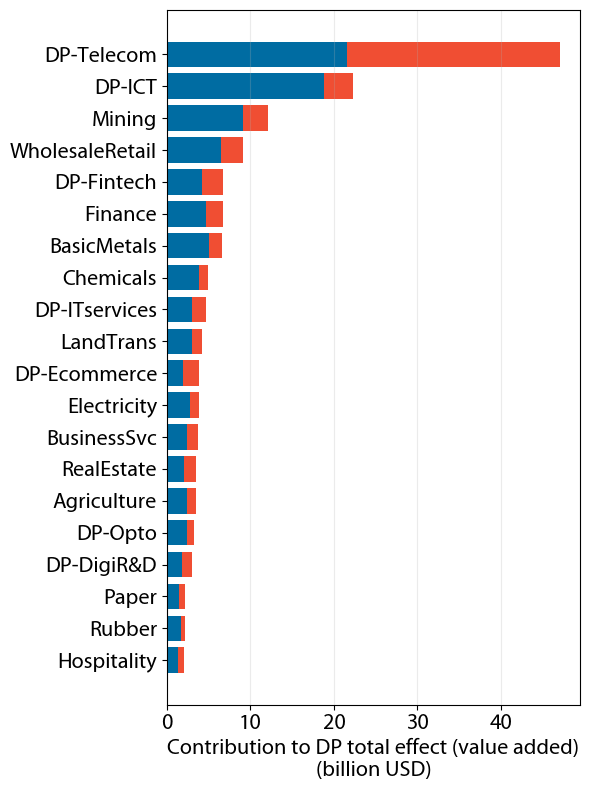

Saved: results/top20_DP_effect_decomposition_2008.png


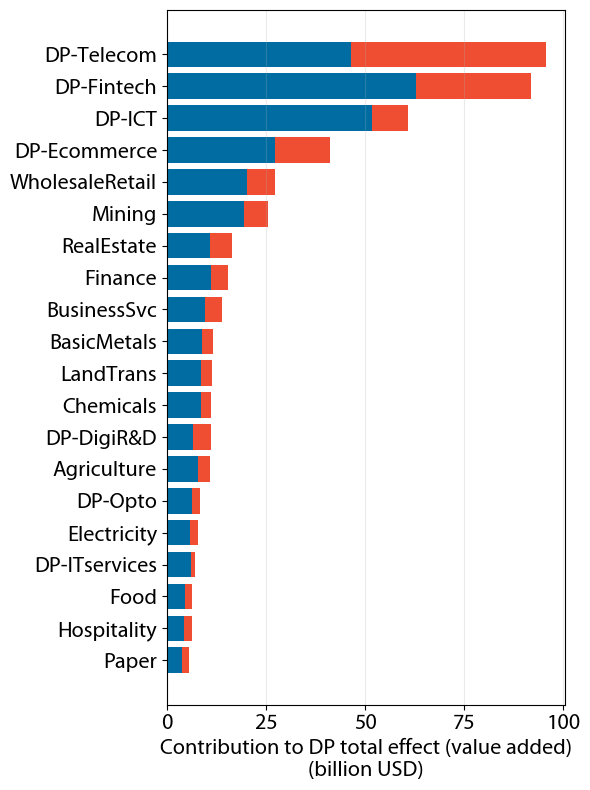

Saved: results/top20_DP_effect_decomposition_2013.png


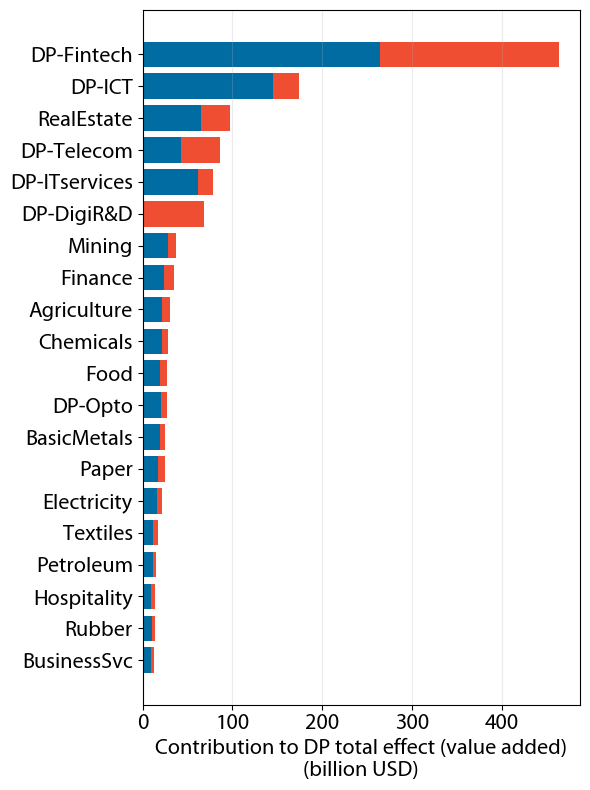

Saved: results/top20_DP_effect_decomposition_2020.png


In [21]:
# FIGURE: Sector decomposition for selected years
# Support vs Final-demand, Top sectors in each year
# =========================
selected_years = [2000, 2008, 2013, 2020]
top_n2 = 20
eps = 1e-12

support_color = "#006CA2"
final_color = "#F04E33"

for yr in selected_years:
    df_year = df[df["year"] == yr].copy()

    # million -> billion
    num_cols = df_year.select_dtypes(include=[np.number]).columns
    df_year[num_cols] = df_year[num_cols] / 1000

    # choose top sectors by DP total effect in each year
    df_year_top = (
        df_year
        .sort_values("DP_TotalEffect_t_i", ascending=False)
        .head(top_n2)
        .iloc[::-1]
        .reset_index(drop=True)
    )

    y_pos = np.arange(len(df_year_top))

    fig, ax = plt.subplots(figsize=(6, 8), facecolor="none")
    ax.barh(
        y_pos,
        df_year_top["DP_Support_t_i"],
        color=support_color,
        label="DP support effect (via supply chains)"
    )
    ax.barh(
        y_pos,
        df_year_top["DP_FinalDemand_t_i"],
        left=df_year_top["DP_Support_t_i"],
        color=final_color,
        label="DP final-demand effect (direct DP consumption)"
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_year_top["sector_name"], fontsize=fs)
    ax.tick_params(axis="x", labelsize=fs)
    ax.tick_params(axis="y", labelsize=fs)
    ax.set_xlabel(
        "Contribution to DP total effect (value added)\n(billion USD)",
        fontsize=fs
    )

    # ax.legend(fontsize=fs, frameon=False, loc="lower right")
    ax.grid(axis="x", alpha=0.25)
    ax.set_facecolor("none")
    save_tight(fig, f"top{top_n2}_DP_effect_decomposition_{yr}.png")
    plt.show()

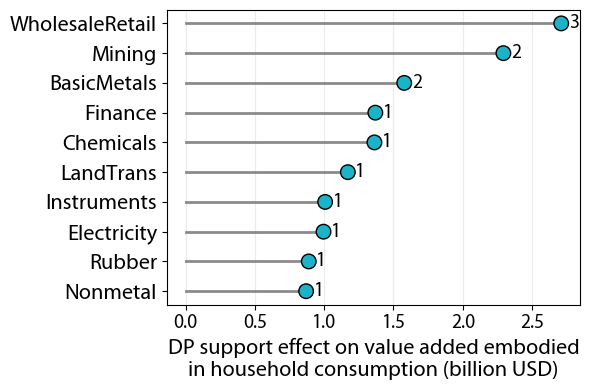

Saved: results/top10_nonDP_hubs_DP_support_2000.png


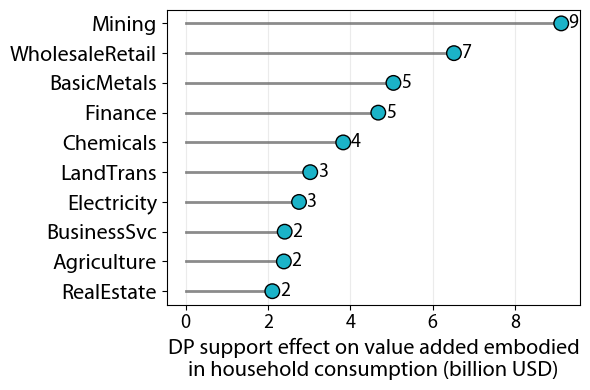

Saved: results/top10_nonDP_hubs_DP_support_2008.png


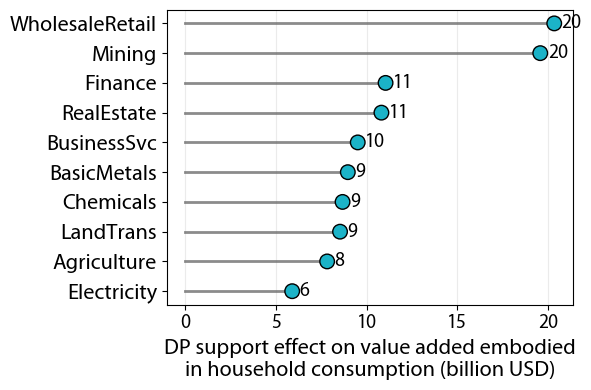

Saved: results/top10_nonDP_hubs_DP_support_2013.png


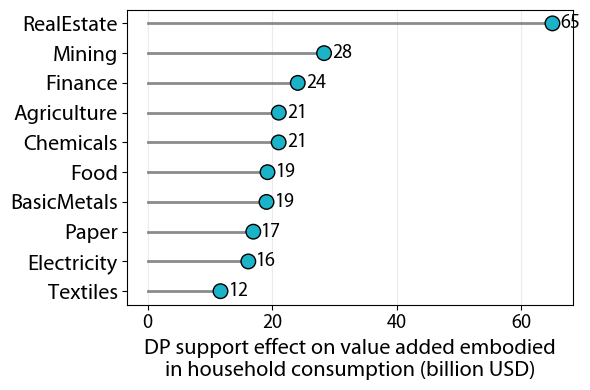

Saved: results/top10_nonDP_hubs_DP_support_2020.png


In [24]:
# FIGURE: Top non-DP hubs by DP support effect in selected years
# Each year selects its own top sectors
# =========================
selected_years = [2000, 2008, 2013, 2020]
top_n = 10

for yr in selected_years:
    # ---- 1) filter: year + non-DP sectors ----
    df_y = df[
        (df["year"] == yr) &
        (df["group"].isin(["NDP"]))
    ].copy()

    df_y["DP_Support_t_i"] = pd.to_numeric(df_y["DP_Support_t_i"], errors="coerce")
    df_y = df_y.dropna(subset=["DP_Support_t_i"])

    # ---- 2) top N hubs by DP support ----
    df_top = (
        df_y
        .sort_values("DP_Support_t_i", ascending=False)
        .head(top_n)
        .copy()
    )
    # reverse order for horizontal plotting
    df_top = df_top.sort_values("DP_Support_t_i", ascending=True).reset_index(drop=True)
    # convert to billion USD if original unit is million USD
    df_top["support_billion"] = df_top["DP_Support_t_i"] / 1000.0
    # ---- 3) lollipop plot ----
    y_pos = np.arange(len(df_top))
    x = df_top["support_billion"].values
    colors = np.where(df_top["group"].values == "NDP", "#1BB3C8", "#999999")

    fig, ax = plt.subplots(figsize=(6, 4), facecolor="none")
    for i in range(len(df_top)):
        ax.plot(
            [0, x[i]],
            [i, i],
            linewidth=2,
            alpha=0.8,
            color="#6E6E6E"
        )
    ax.scatter(
        x,
        y_pos,
        s=110,
        color=colors,
        edgecolor="black",
        linewidth=1.0,
        zorder=3
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_top["sector_name"], fontsize=fs)
    ax.set_xlabel(
        "DP support effect on value added embodied\nin household consumption (billion USD)",
        fontsize=fs
    )
    ax.tick_params(axis="x", labelsize=fss)
    ax.tick_params(axis="y", labelsize=fs)

    # annotate values to the right of each dot
    offset = x.max() * 0.02 if x.max() > 0 else 0.02
    for i in range(len(df_top)):
        ax.text(
            x[i] + offset,
            i,
            f"{x[i]:.0f}",
            va="center",
            ha="left",
            fontsize=fss
        )
    ax.grid(axis="x", alpha=0.25)
    ax.set_facecolor("none")
    save_tight(fig, f"top{top_n}_nonDP_hubs_DP_support_{yr}.png")
    plt.show()

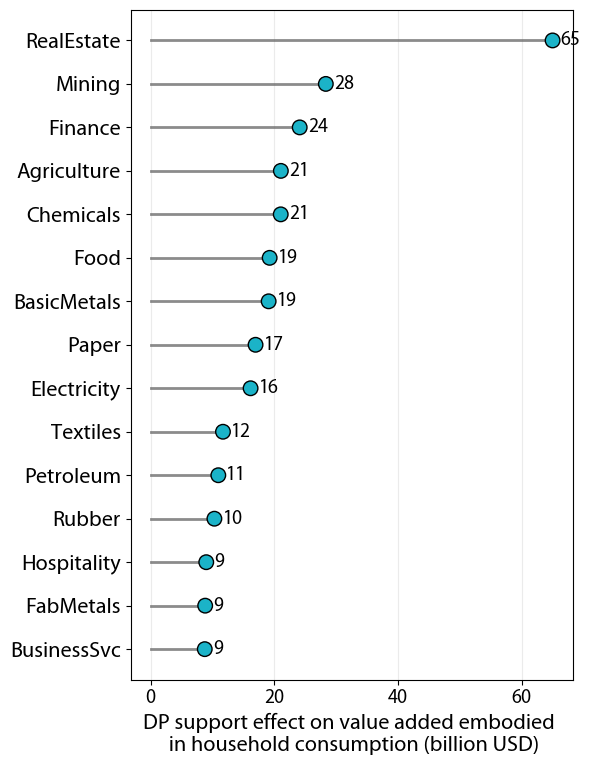

Saved: results/top15_nonDP_hubs_DP_support_2020.png


In [ ]:
# ---- 1) filter: year + non-DP sectors (NDP) ----
df_y = df20[df20["group"].isin(["NDP"])].copy()
df_y["DP_Support_t_i"] = pd.to_numeric(df_y["DP_Support_t_i"], errors="coerce")
df_y = df_y.dropna(subset=["DP_Support_t_i"])

# ---- 2) top N hubs by DP support ----
df_top = df_y.sort_values("DP_Support_t_i", ascending=False).head(15).copy()
df_top = df_top.sort_values("DP_Support_t_i", ascending=True).reset_index(drop=True)

# convert to billion USD (if VALUE_COL is in million USD)
df_top["support_billion"] = df_top["DP_Support_t_i"] / 1000.0

# ---- 3) lollipop plot ----
y_pos = np.arange(len(df_top))
x = df_top["support_billion"].values

colors = np.where(df_top["group"].values == "NDP", "#1BB3C8", "#999999")

fig, ax = plt.subplots(figsize=(6, 8), facecolor="none")
for i in range(len(df_top)):
    ax.plot([0, x[i]], [i, i], linewidth=2, alpha=0.8, color="#6E6E6E")

ax.scatter(x, y_pos, s=110, color=colors, edgecolor="black", linewidth=1.0, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_top["sector_name"], fontsize=fs)
ax.set_xlabel("DP support effect on value added embodied \n in household consumption (billion USD)", fontsize=fs)
ax.tick_params(axis="x", labelsize=fss)

# annotate values to the right of each dot
offset = x.max() * 0.02 if x.max() > 0 else 0.02
for i in range(len(df_top)):
    ax.text(x[i] + offset, i, f"{x[i]:.0f}", va="center", ha="left", fontsize=fss)

# from matplotlib.lines import Line2D
# legend_elems = [
#     Line2D([0], [0], marker='o', color='none', label='NDP', markerfacecolor="#999999", markersize=9),
#     Line2D([0], [0], marker='o', color='none', label='DCP', markerfacecolor="#1BB3C8", markersize=9),
# ]
# ax.legend(handles=legend_elems, frameon=False, fontsize=fs, loc="lower right")

ax.grid(axis="x", alpha=0.25)
ax.set_facecolor("none")
save_tight(fig, f"top15_nonDP_hubs_DP_support_2020.png")

In [49]:
print(df_top["sector_name"], df_top["support_billion"])

0     BusinessSvc
1       FabMetals
2     Hospitality
3          Rubber
4       Petroleum
5        Textiles
6     Electricity
7           Paper
8     BasicMetals
9            Food
10      Chemicals
11    Agriculture
12        Finance
13         Mining
14     RealEstate
Name: sector_name, dtype: object 0      8.743827
1      8.811011
2      8.984285
3     10.301990
4     10.934943
5     11.688746
6     16.155173
7     16.956849
8     19.075521
9     19.238029
10    21.029228
11    21.048859
12    24.096668
13    28.319719
14    64.992065
Name: support_billion, dtype: float64


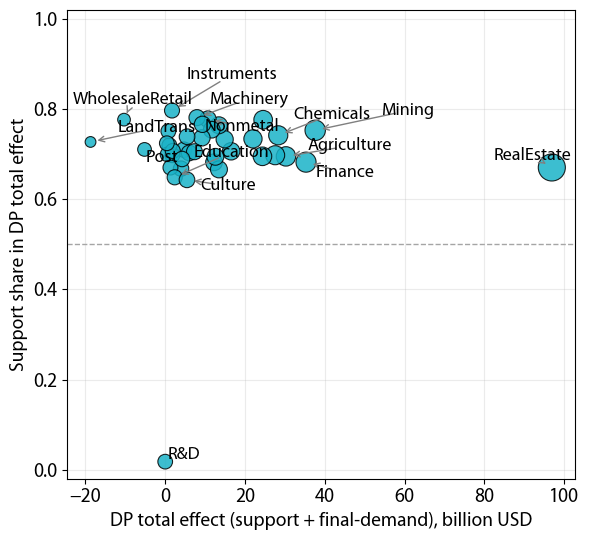

Saved: results/composition_map_nonDP_total_vs_supportshare_2020.png


In [55]:
df_nonDP = df20[df20["group"].isin(["NDP"])].copy()
df_nonDP["support_bil"] = df_nonDP["DP_Support_t_i"] / 1000
df_nonDP["final_bil"]   = df_nonDP["DP_FinalDemand_t_i"] / 1000
df_nonDP["total_bil"]   = (df_nonDP["DP_Support_t_i"] + df_nonDP["DP_FinalDemand_t_i"]) / 1000
eps = 1e-6  # to avoid log(0)
df_nonDP["support_share"] = df_nonDP["support_bil"] / (df_nonDP["total_bil"] + eps)

fig, ax = plt.subplots(figsize=(6, 5.5), facecolor="none")
color_map = {"NDP": "#1BB3C8", "DCP": "#999999"}
# size encode total effect (bigger = larger total)
tmin, tmax = df_nonDP["total_bil"].min(), df_nonDP["total_bil"].max()
# avoid division by zero if all totals are equal
if tmax > tmin:
    size = 60 + (df_nonDP["total_bil"] - tmin) / (tmax - tmin) * (380 - 60)
else:
    size = np.full(len(df_nonDP), 160.0)

for g in ["NDP", "DCP"]:
    sub = df_nonDP[df_nonDP["group"] == g]
    ax.scatter(
        sub["total_bil"],
        sub["support_share"],
        s=size[sub.index],
        color=color_map[g],
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        label=g,
        zorder=3
    )

# reference line: 50% support share
ax.axhline(0.5, linestyle="--", color="gray", linewidth=1, alpha=0.7, zorder=1)

ax.set_xlabel("DP total effect (support + final-demand), billion USD", fontsize=fss)
ax.set_ylabel("Support share in DP total effect", fontsize=fss)
ax.set_ylim(-0.02, 1.02)

ax.tick_params(axis="both", labelsize=fss)
ax.grid(alpha=0.25)
ax.set_facecolor("none")

# ax.legend(frameon=False, fontsize=fss, loc="lower right")

# 1) DP total effect: top 5 and bottom 3
df_top_total = df_nonDP.nlargest(5, "total_bil").copy()
df_bot_total = df_nonDP.nsmallest(3, "total_bil").copy()

# 2) support_share: top 3 and bottom 3
df_top_share = df_nonDP.nlargest(3, "support_share").copy()
df_bot_share = df_nonDP.nsmallest(3, "support_share").copy()

# combine + deduplicate by sector_name (or sector_index if you prefer)
df_annot = pd.concat([df_top_total, df_bot_total, df_top_share, df_bot_share], ignore_index=True)
df_annot = df_annot.drop_duplicates(subset=["sector_name"]).copy()
# --- annotate ---
texts = []
for _, r in df_annot.iterrows():
    # optional: add a tiny offset so text doesn't sit exactly on the marker
    texts.append(
        ax.text(
            r["total_bil"],
            r["support_share"],
            str(r["sector_name"]),
            fontsize=fss - 1,
            zorder=5
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(
        arrowstyle="->",
        color="gray",
        lw=1,
        shrinkA=10,   # distance from text
        shrinkB=5     # distance from point
    ),
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2)
)

save_tight(fig, "composition_map_nonDP_total_vs_supportshare_2020.png")